### ANSWER

# Homework 3 Template (Loading, Cleaning, Analyzing, and Visualizing Data with Pandas (and using resources!))

### ANSWER

## README

These templates have been drafted to standardize the homework assignments to the course learning objectives and keep them of similar difficulty, length, and point values throughout the semester. 
Homework drafts are due to the Lead Instructor and Associate Instructors at least **7 days** prior to their release date in order to give instructors enough time to review the assignment, the assignment lead enough time to integrate feedback, and all staff enough time to review the final assignment prior to release. 

It is expected that the assignments follow the learning objectives and the general structure/point distribution provided, but the framing of the problems is left up to the assignment lead(s). A specific rubric should be included with the finished assignment to foster equity in grading across sections. It is encouraged to explore a variety of discipline areas in the problem framing, particularly those represented by our students (biology, chemistry, data science, physics, astronomy, business, etc.)! Some example questions have been provided for reference. If you have questions about your homework assignment as you develop it, they can be directed to the lead instructor.

Please make sure to include "metacognition" questions along the way where students are explicitly asked to describe how they solved a problem, what external resources they used (or how they knew how to do the problem if they didn't need resources). It is critical for them to engage in this so that they know they are learning and we can see that they are learning!

Finally, homework assignments are designed to assess the material covered in the Pre-class and In Class assignments and should therefore **not contain anything that is not covered in those assignments.** 

## Overall Structure (Suggested - feel free to adjust order)
1. Academic Integrity
2. Loading/cleaning data
   * Identify a robust data set that students will load and clean (ideally a csv)
   * Ask them to do exploratory data analysis (e.g. calculate descriptive statistics, make simple line plots or histograms, etc.)
   * Ask them to make claims supported by evidence and reasoning about what they see
   * Metacognition: Documenting solution pathways
3. Making meaningful visualizations (with resources)
   * Provide some data in the notebook (or provide them a clean data file that reads in easily)
   * Have students identify plotting code to tinker with from an external source (not class assigments)
   * Have students make a plot to visualize the data and then make claims (supported by evidence and reasoning) related to the data
   * MetacognitionL Documenting solution pathways
4. Linear Regression (could be combine with previous parts)
   * Using data from either part 2 or part 3, ask folks to do regression on the data
   * Ask them to make a prediction (i.e. use the regression to project future behavior)
   * Metacognition: Documenting solution pathways

### Learning Goals Assessed in this homework
* Using pandas to work with data and clean it
* Make meaningful visual representations of the data
* Fitting curves to data and evaluating model fits

Below are some questions that *loosely* follow the template (and are from Homework 3 Fall 2023) for this homework assignment, but feel free to also look at past assignments!
**Note:** Please look at Homework 1 and Homework 2 for examples of metacognition questions! (That is new this semester)

# Homework 3: Loading, Cleaning, Analyzing, and Visualizing Data with Pandas (and using resources!)

### <p style="text-align: right;"> &#9989; Put your name here </p>

## Learning Goals

* Using pandas to work with data and clean it
* Make meaningful visual representations of the data
* Fitting curves to data and evaluating model fits

___

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, November 1, 2024** 

It should be uploaded into D2L Homework #3.  Submission instructions can be found at the end of the notebook.

---
<a id="toc"></a>

## Table of Contents

[Part 0. Academic Integrity Statement](#part_0) (2 points)

[Part 1. Reading, describing, and cleaning data](#part_1)  (22 points)

[Part 2. Exploratory Data Analysis and Data visualization](#part_2)  (20 points)

[Part 3. Fitting curves to data.](#part_3) (18 points)
    

---
<a id="part_0"></a>

## Part 0. Academic integrity statement (2 points)

[Back to Top](#toc)

In the markdown cell below, paste your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

<font size=6 color="#009600">&#9998;</font> *Put your personal academic integrity statement here.*

Before we read in the data and begin working with it, let's import the libraries that we would typically use for this task. You can always come back to this cell and import additional libraries that you need.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.optimize import curve_fit

---
<a id="part_1"></a>

## Part 1: Data Reading and Cleaning (20 points total)

[Back to Top](#toc)

Suppose you are interested in modeling the weather of the Great Lakes.  You find some great data in the [Great Lakes Weather Data and Marine Observations](https://apps.glerl.noaa.gov/marobs/)$^{1}$ webpage that has been compiled by the [Great Lakes Environmental Research Laboratory](https://www.glerl.noaa.gov/about/), a lab that operates under NOAA. Let's check it out!


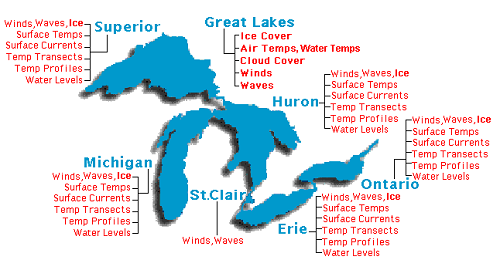Image credit: [NOAA GLERL](https://www.glerl.noaa.gov/res/Programs/ipemf/GLCFS_nextgen.html)


The data contains realtime marine data from Great Lakes buoys, coastal met stations, airports, and ships. Marine observations include wind speed, wind gust, wind direction, air temperature, dew point, cloud cover, sea level pressure, water temperature, wave height, wave period, and live tracking of Great Lakes ship locations.

Variables are descibed as follows:

| Variable name   |    stands for            |    unit of measurement         |  
|:---------------:|:------------------------:|--------------------------------| 
| id              | Observation Identifier   | includes 'year', 'day', 'hour', 'minute', 'station type', 'station id' and 'lake'|
| data_format     | data format              | 9 = Lake Meteorological Data (LMD) Format| 
| air_temp        | Air temperature          | degrees Centigrade             | 
| dew_point          | Dew point                | degrees Centigrade             | 
| wind_direction        | Wind direction           | degrees from, 0=north, 90=east | 
| wind_speed        | Wind speed               | meters/second                  |
| max_gust        | Maximum wind gust        | meters/second                  | 
| cloud       | Cloud cover              | percent                        | 
| solar       | Solar Radiation          | watts/meter                    | 
| pressure        | Barometric pressure      | millibars                      |
| water_temp      | Water temperature        | degrees Centigrade             | 
| wave_height         | Significant Wave height  | meters                         | 
| wave_period        | Wave period              |   seconds                             | 
|ship_lat |      North Latitude (ship observation)                 | Decimal degrees                   |                       |
|ship_long  |  West Longitude (ship observation)                  |    Decimal degrees                 |                       |




$^{1}$NOAA/GLERL. Realtime Great Lakes Weather Data and Marine Observations. https://apps.glerl.noaa.gov/marobs/, accessed March 3rd, 2025.


## Part 1.1 - Looking over the data (2 points)
As you might recall from Day 12, data sometimes comes in formats that you might not be familiar with.  Figuring out how to load in the data in a useful way is one of the most common issues that you will face.  In the cell below, try reading in the data from `g202502600.lmd` using `read_csv`.  

In [17]:
# Run this cell!
problem_data = pd.read_csv('g202502600.lmd')
problem_data.head()

,202502600001AGCM4 29 999.9 999.9 999 99.9 99.9 999 9999.9 1015.4 0.1 99.9 99.9
0,202502600001ALXN6 59 999.9 999.9 999 99.9 99...
1,202502600001APNM4 29 -1.2 999.9 260 6.2 7...
2,202502600001BHRI3 19 2.5 999.9 270 5.7 7...
3,202502600001BIGM4 09 -2.4 999.9 330 3.6 7...
4,202502600001BSBM4 19 1.0 999.9 270 16.5 21...


You probably saw that data did not load correctly.  Open the data and take a look at the file.  You might also want to look at the format sheet that is provided on the website: https://apps.glerl.noaa.gov/marobs/docs/data.lmd.fmt. 

#### &#9989;&nbsp; **Task**
**Name at least two things about how the data is formatted that might make it hard for `read_csv` to read in the data.**(2 points)

<font size=8 color="#009600">&#9998;</font> Put your answer here:  

### ANSWER ###
One point for each item listed, for max of 2 points
1. Separated by whitespace, not commas
2. Separation is variable size
3. The lines for ships have more info (the fields given by nn.nn and oo.oo at the end)

## Part 1.2 Loading Data (5 points)

It appears we might need to use a different tool to read in the data.  Take a look at the tools pandas has available, and read some of the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html.  Is there one that looks like it might be useful in this case?  

#### &#9989;&nbsp; **Task (1 points)**
**Test out the tool you selected and print the first few rows to make sure it works.  Make sure the columns have appropriate descriptive names!**  
*If all goes well, you should get something that looks like this:*

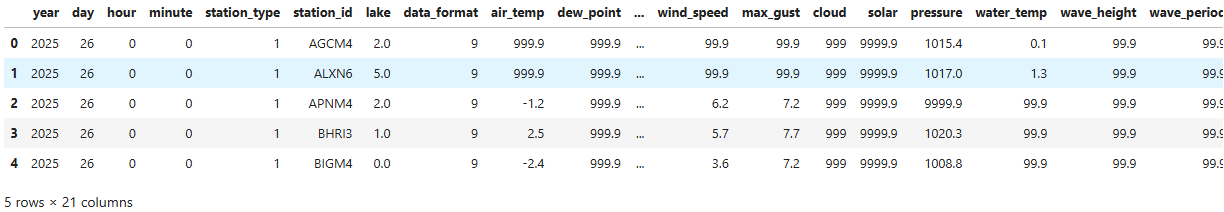

In [22]:
## your code here

In [23]:
### ANSWER ###
colspecs = [(0,4), (4,7), (7,9), (9,11), (11,12), (12,20), (20,21), (21,22), (23,28),(29,34), (35,38), (39,43), (44,48), (49,53), (53,59), (60,66), (67,71), (72,76), (77,81), (82,87), (88,93)]
names = ['year', 'day', 'hour', 'minute', 'station_type', 'station_id', 'lake', 'data_format', 'air_temp', 'dew_point', 'wind_direction', 'wind_speed', 'max_gust', 'cloud', 'solar', 'pressure', 'water_temp', 'wave_height', 'wave_period', 'ship_lat', 'ship_long']
data = pd.read_fwf('g202502600.lmd',header=None,colspecs=colspecs,names=names)
data.head()

# rubric:
# 2 point read_fwf
# 1 point appropriate columns
    # (can use colspecs or widths when loading in, 
    #  students might also load in and then change columns after loaded in)
# 1 point named columns
# 1 point print out first rows

,year,day,hour,minute,station_type,station_id,lake,data_format,air_temp,dew_point,...,wind_speed,max_gust,cloud,solar,pressure,water_temp,wave_height,wave_period,ship_lat,ship_long
0,2025,26,0,0,1,AGCM4,2.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1015.4,0.1,99.9,99.9,NaN,NaN
1,2025,26,0,0,1,ALXN6,5.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1017.0,1.3,99.9,99.9,NaN,NaN
2,2025,26,0,0,1,APNM4,2.0,9,-1.2,999.9,...,6.2,7.2,999,9999.9,9999.9,99.9,99.9,99.9,NaN,NaN
3,2025,26,0,0,1,BHRI3,1.0,9,2.5,999.9,...,5.7,7.7,999,9999.9,1020.3,99.9,99.9,99.9,NaN,NaN
4,2025,26,0,0,1,BIGM4,0.0,9,-2.4,999.9,...,3.6,7.2,999,9999.9,1008.8,99.9,99.9,99.9,NaN,NaN


## Part 1.3 Loading multiple files (4 points)

Each file only includes data from a single day, which might not be very useful.  It would be much more useful to load in data from multiple days.  This is a very common thing to do in data science.  Fortunately, we can accomplish this in python!

You have been provided with 30 data files, corresponding to daily marine data observations from day 26 to day 57 of the year 2025.

#### &#9989;&nbsp; **Task:** 
Write a `for` loop to load in the data from each of the files and save all of the data into one dataframe.  Print out the final dataframe.** In each iteration of the loop, you will change the name of the file to be loaded in.  Some example starter code is provided to you to get you started, you will have to modify it. In this example, the code reads in a series of datasets with file names "Example001.csv", "Example002.csv", "Example003.csv", and so on.

In [25]:
# create an empty dataframe
# this is where all the data will eventually be stored
store_data = pd.DataFrame() 

# create a filename
filenumber = "{:03d}".format(2)
filename = "Example" + filenumber + ".csv"
print(filename)

# load in data to a temporary variable
temp_data = pd.read_csv(filename)

# add data to the storage variable 
store_data = pd.concat([store_data, temp_data])
store_data

Example002.csv


,tag_1,air_temp,dew_pt,wind_dir,wind_spd,wind_gst,cloud_cvr,solar_rad,bar_pres,water_temp,wave_ht,wave_per
0,29,5.8,999.9,999,99.9,99.9,999,9999.9,1008.2,0.1,99.9,99.9
1,59,999.9,999.9,999,99.9,99.9,999,9999.9,1005.3,0.8,99.9,99.9
2,29,3.1,999.9,300,1.0,1.0,999,9999.9,9999.9,99.9,99.9,99.9
3,19,2.5,999.9,90,1.0,1.5,999,9999.9,1012.2,99.9,99.9,99.9
4,9,-0.7,999.9,0,0.0,0.0,999,9999.9,1009.1,99.9,99.9,99.9
...,...,...,...,...,...,...,...,...,...,...,...,...
724,29,1.0,-1.0,360,1.5,99.9,100,9999.9,9999.9,99.9,99.9,99.9
725,9,1.0,-3.0,0,0.0,99.9,0,9999.9,9999.9,99.9,99.9,99.9
726,49,4.0,0.0,250,1.5,99.9,0,9999.9,9999.9,99.9,99.9,99.9
727,9,2.0,-2.0,0,0.0,99.9,0,9999.9,9999.9,99.9,99.9,99.9


In [196]:
### ANSWER ###

# create an empty dataframe
# this is where all the data will eventually be stored
store_data = pd.DataFrame() 

for i in range(26,57):
    # create a filename
    filenumber = "{:03d}".format(i)
    filename = "g2025" + filenumber + "00.lmd"
    print(filename)
    
    # load in data to a temporary variable
    temp_data = pd.read_fwf(filename,header=None,colspecs=colspecs,names=names)
    
    # add data to the storage variable 
    store_data = pd.concat([store_data, temp_data])

store_data

# Rubric:
# 1 point appropriate for loop
# 1 point change file name
# 1 point correct data 
# 1 point display 

g202502600.lmd
g202502700.lmd
g202502800.lmd
g202502900.lmd
g202503000.lmd
g202503100.lmd
g202503200.lmd
g202503300.lmd
g202503400.lmd
g202503500.lmd
g202503600.lmd
g202503700.lmd
g202503800.lmd
g202503900.lmd
g202504000.lmd
g202504100.lmd
g202504200.lmd
g202504300.lmd
g202504400.lmd
g202504500.lmd
g202504600.lmd
g202504700.lmd
g202504800.lmd
g202504900.lmd
g202505000.lmd
g202505100.lmd
g202505200.lmd
g202505300.lmd
g202505400.lmd
g202505500.lmd
g202505600.lmd


,year,day,hour,minute,station_type,station_id,lake,data_format,air_temp,dew_point,...,wind_speed,max_gust,cloud,solar,pressure,water_temp,wave_height,wave_period,ship_lat,ship_long
0,2025,26,0,0,1,AGCM4,2.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1015.4,0.1,99.9,99.9,NaN,NaN
1,2025,26,0,0,1,ALXN6,5.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1017.0,1.3,99.9,99.9,NaN,NaN
2,2025,26,0,0,1,APNM4,2.0,9,-1.2,999.9,...,6.2,7.2,999,9999.9,9999.9,99.9,99.9,99.9,NaN,NaN
3,2025,26,0,0,1,BHRI3,1.0,9,2.5,999.9,...,5.7,7.7,999,9999.9,1020.3,99.9,99.9,99.9,NaN,NaN
4,2025,26,0,0,1,BIGM4,0.0,9,-2.4,999.9,...,3.6,7.2,999,9999.9,1008.8,99.9,99.9,99.9,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17008,2025,56,23,56,6,TTF,4.0,9,7.0,1.0,...,3.1,99.9,0,9999.9,9999.9,99.9,99.9,99.9,NaN,NaN
17009,2025,56,23,56,6,VPZ,1.0,9,4.0,-1.0,...,2.6,99.9,0,9999.9,1012.3,99.9,99.9,99.9,NaN,NaN
17010,2025,56,23,57,6,MNM,1.0,9,4.0,-4.0,...,2.1,99.9,0,9999.9,1010.4,99.9,99.9,99.9,NaN,NaN
17011,2025,56,23,57,6,SUE,1.0,9,2.0,0.0,...,3.6,99.9,0,9999.9,1010.5,99.9,99.9,99.9,NaN,NaN


## Part 1.4: Slicing and performing basic statistics on data (3 points)

#### 1.4a Building a weather prediction model (2 points)

Determine six variables (columns), aside the first seven columns, that you will use in your lake weather model.

#### &#9989;&nbsp; **Task** 
Note down the six variables of your choice.

**ANSWER**
Any list of six variables from among the measurements. 

2/2 points for 6 variables correctly listed.

1/2 points if any of chosen variables is an identifier, like `year`, `day`, `hour`, `minute`, `station_type`, `station_id`, `lake`, or `data_format`.

In the answers that follow, we use the variables in the list `['air_temp', 'wind_speed', 'wind_direction', 'pressure', 'max_gust', 'dew_point']`, for instance.


#### 1.4b Slicing data (1 point)
Using the `iloc` function, create a new data frame that has only the first seven columns and the six that you have chosen.  

In [ ]:
#your code here

In [230]:
#ANSWER

store_data_2=store_data.iloc[:,0:14]
store_data_2.describe()


#ALTERNATE ANSWER WITHOUT ILOC:
# var_list=['year', 'day', 'hour', 'minute', 'station_type', 'station_id', 'lake', 'data_format', 'air_temp', 'wind_speed', 'wind_direction', 'pressure', 'max_gust', 'dew_point']
# store_data=store_data[var_list]

## 1 point for correct code that runs without errors
## 0 points if code does not run

,year,day,hour,minute,station_type,lake,data_format,air_temp,wind_speed,pressure,max_gust
count,517062.0,517062.000000,517062.000000,517062.000000,517062.000000,511130.000000,517062.0,517062.000000,517062.000000,517062.000000,517062.000000
mean,2025.0,41.085907,11.479308,27.382906,2.198522,2.015341,9.0,188.641409,30.241642,4615.300551,55.137313
std,0.0,8.939066,6.913900,19.016671,2.118890,1.684279,0.0,396.592512,42.228451,4401.217539,46.406104
min,2025.0,26.000000,0.000000,0.000000,0.000000,0.000000,9.0,-35.000000,0.000000,964.700000,0.000000
25%,2025.0,33.000000,5.000000,10.000000,1.000000,1.000000,9.0,-7.700000,3.100000,1016.400000,6.700000
50%,2025.0,41.000000,11.000000,30.000000,1.000000,2.000000,9.0,-3.400000,5.700000,1028.100000,99.900000
75%,2025.0,49.000000,17.000000,45.000000,1.000000,4.000000,9.0,3.000000,99.900000,9999.900000,99.900000
max,2025.0,56.000000,23.000000,59.000000,6.000000,6.000000,9.0,999.900000,99.900000,9999.900000,99.900000


#### 1.4b Descriptive statistics (1 point)
Now that you have 30 days worth of data loaded in for your weather model, it is a good time to look at the data and see what you have. 

#### &#9989;&nbsp; **Task**
Use the `.describe()` method on your dataset to get some statistics.

In [28]:
#your code here:

In [232]:
### ANSWER
store_data.describe()
# 1 point

,year,day,hour,minute,station_type,lake,data_format,air_temp,wind_speed,pressure,max_gust
count,517062.0,517062.000000,517062.000000,517062.000000,517062.000000,511130.000000,517062.0,517062.000000,517062.000000,517062.000000,517062.000000
mean,2025.0,41.085907,11.479308,27.382906,2.198522,2.015341,9.0,188.641409,30.241642,4615.300551,55.137313
std,0.0,8.939066,6.913900,19.016671,2.118890,1.684279,0.0,396.592512,42.228451,4401.217539,46.406104
min,2025.0,26.000000,0.000000,0.000000,0.000000,0.000000,9.0,-35.000000,0.000000,964.700000,0.000000
25%,2025.0,33.000000,5.000000,10.000000,1.000000,1.000000,9.0,-7.700000,3.100000,1016.400000,6.700000
50%,2025.0,41.000000,11.000000,30.000000,1.000000,2.000000,9.0,-3.400000,5.700000,1028.100000,99.900000
75%,2025.0,49.000000,17.000000,45.000000,1.000000,4.000000,9.0,3.000000,99.900000,9999.900000,99.900000
max,2025.0,56.000000,23.000000,59.000000,6.000000,6.000000,9.0,999.900000,99.900000,9999.900000,99.900000


## Part 1.5: Data cleaning (4 points)

Take a look at the results from the describe function.  In particular, take a look at some of mean and max values, especially for air temperature.  Do those make sense to you?

#### 1.5a &#9989;&nbsp; **Task**: 
You may have noticed there are a lot of places in the data that are filled with the digit 9.  **According to the [format guide](https://apps.glerl.noaa.gov/marobs/docs/data.lmd.fmt), what does this mean?** (1 point)

<font size=8 color="#009600">&#9998;</font> Put your answer here:  

#### Answer: 
1 point - 99999 means no value available

#### 1.5b &#9989;&nbsp; **Task**: 
Use the [`replace()` method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html) in pandas to make these values something more suitable. (2 points)

In [34]:
#your code here

In [234]:
### ANSWER
store_data_rmnan = store_data
store_data_rmnan = store_data_rmnan.replace(999.9,np.nan)
store_data_rmnan = store_data_rmnan.replace(99.9,np.nan)
store_data_rmnan = store_data_rmnan.replace(999,np.nan)
store_data_rmnan = store_data_rmnan.replace(9999.9,np.nan)
store_data_rmnan.describe()


# 2 points - use replace appropriately - could use pd.NA instead of np.nan

,year,day,hour,minute,station_type,lake,data_format,air_temp,wind_speed,pressure,max_gust
count,517062.0,517062.000000,517062.000000,517062.000000,517062.000000,511130.000000,517062.0,417341.000000,378520.000000,309433.000000,249727.000000
mean,2025.0,41.085907,11.479308,27.382906,2.198522,2.015341,9.0,-5.203715,4.746006,1017.921922,7.218453
std,0.0,8.939066,6.913900,19.016671,2.118890,1.684279,0.0,5.761620,3.147978,10.047526,4.206349
min,2025.0,26.000000,0.000000,0.000000,0.000000,0.000000,9.0,-35.000000,0.000000,964.700000,0.000000
25%,2025.0,33.000000,5.000000,10.000000,1.000000,1.000000,9.0,-8.800000,2.600000,1011.300000,4.100000
50%,2025.0,41.000000,11.000000,30.000000,1.000000,2.000000,9.0,-5.000000,4.100000,1018.800000,6.700000
75%,2025.0,49.000000,17.000000,45.000000,1.000000,4.000000,9.0,-1.500000,6.200000,1025.900000,9.800000
max,2025.0,56.000000,23.000000,59.000000,6.000000,6.000000,9.0,14.000000,71.000000,1080.300000,38.600000


#### 1.5c &#9989;&nbsp; **Task**: 
Does this make the values returned by `.describe()` make more sense to you? (1 point)

<font size=8 color="#009600">&#9998;</font> Put your answer here:  

#### Answer
1 point - describe values make more sense

NOTE: certain columns (e.g. dew point, wind direction) may load into pandas as strings - that does not affect describe

#### Now, create a new data frame that does not have the `"NaN"` values. 

#### 1.5d &#9989;&nbsp; **Task:** 
Remove the missing values using the built-in pandas [`dropna()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html) function. (1 point) 

In [ ]:
#your code here

In [236]:
#ANSWER
clean_lake_data = store_data_rmnan.dropna()
clean_lake_data


,year,day,hour,minute,station_type,station_id,lake,data_format,air_temp,wind_speed,wind_direction,pressure,max_gust,dew_point
3,2025,26,0,0,1,BHRI3,1.0,9,2.5,5.7,270,1020.3,7.7,999.9
4,2025,26,0,0,1,BIGM4,0.0,9,-2.4,3.6,330,1008.8,7.2,999.9
5,2025,26,0,0,1,BSBM4,1.0,9,1.0,16.5,270,1014.6,21.1,999.9
10,2025,26,0,0,1,CLSM4,3.0,9,-0.9,4.1,200,1017.3,6.7,999.9
14,2025,26,0,0,1,CYGM4,2.0,9,-1.0,10.8,270,1009.0,19.5,-3.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16951,2025,56,23,54,1,MRHO1,4.0,9,8.8,2.1,230,1008.4,3.1,1.8
16954,2025,56,23,54,1,OSGN6,5.0,9,2.8,4.6,280,1005.7,5.7,1.3
16961,2025,56,23,54,1,THRO1,4.0,9,9.6,4.1,280,1008.5,5.7,0.6
16962,2025,56,23,54,1,WNEM4,2.0,9,-0.2,4.6,300,1009.0,6.2,-4.0


#### Now, examine the difference in sizes between the original and clean datasets. 

#### 1.5e &#9989;&nbsp; **Task:** 
Determine the number of rows in each of them (1 point). Print out your results (1 point).

In [ ]:
#Your code here

In [238]:
## ANSWER
print("The length of the original dataset is", len(store_data_rmnan))
print("The length of the original dataset is", len(clean_lake_data))

The length of the original dataset is 517062
The length of the original dataset is 141140




#### 1.5f &#9989;&nbsp; **Task:**
Let's reflect on the cleaning process. For this specific dataset and the variables you selected, would it matter if you hadn't dropped the `"NaN"` data? (1 point).

<font size=8 color="#009600">&#9998;</font> Put your answer here


#### ANSWER (1 point)
Yes, it does matter; the dataset shrinks in size after the NaNs are removed.

Note they may add (based on Part 2) that NaN's interfere with fitting curves and from that perspective the NaNs do matter.

## Part 1.6 - Filter the data using masking (6 points)

Now you have a clean dataset for your weather model. Suppose you want to see if the weather on the west side of Lake Michigan is correlated with the weather on the east side of Lake Michigan.  

#### 1.6a &#9989;&nbsp; **Task**: Choose three stations on the east side of Lake Michigan and three stations on the west side of Lake Michigan.  (Hint: Use the [map](https://apps.glerl.noaa.gov/marobs/php/data.php?sta=9&labels=n&param=5&units=e&zoom=m) to see where each station is located).  Which stations did you choose? (2 points)

#### 1.6b &#9989;&nbsp; **Task**: Use masking to isolate data for each of those stations. (2 points)

<font size=8 color="#009600">&#9998;</font> Put your answer here:  

**1.6a**  


#### Answer
2/2 points - choosing 3 stations on each side

1/2 points - choosing less than 3 on either side

In [42]:
#1.6b
#your code here:

In [208]:
### ANSWER ###

# west of L. Mich.
# chicago
data_CHI = clean_lake_data[clean_lake_data['station_id']=='UGN']
data_CHI.describe()

# # # milwaukee
data_MKE = clean_lake_data[clean_lake_data['station_id']=='MKE']
data_MKE

# # # sheboygan
data_SBM = clean_lake_data[clean_lake_data['station_id']=='SBM']
data_SBM.describe()


# # # east of L. Mich.
# # # Holland
data_HOL = clean_lake_data[clean_lake_data['station_id']=='BIV']
data_HOL

# # # Muskegon
data_MKG = clean_lake_data[clean_lake_data['station_id']=='MKG']
data_MKG

# # # benton harbor
data_BEH = clean_lake_data[clean_lake_data['station_id']=='BEH']
data_BEH.describe()

# rubric
# 2/2 points - correct masking
# 1/2 points - attempt at masking but not successful

,year,day,hour,minute,station_type,lake,data_format,air_temp,wind_speed,pressure,max_gust
count,51.0,51.000000,51.000000,51.0,51.0,51.0,51.0,51.000000,51.000000,51.000000,51.000000
mean,2025.0,41.705882,12.078431,53.0,6.0,1.0,9.0,-3.215686,8.178431,1018.770588,15.641176
std,0.0,8.232361,7.858354,0.0,0.0,0.0,0.0,4.738412,1.809565,6.883525,1.627781
min,2025.0,26.000000,0.000000,53.0,6.0,1.0,9.0,-11.000000,4.600000,1005.600000,13.400000
25%,2025.0,37.500000,3.500000,53.0,6.0,1.0,9.0,-6.000000,6.700000,1013.350000,14.400000
50%,2025.0,47.000000,15.000000,53.0,6.0,1.0,9.0,-3.000000,8.200000,1020.200000,15.400000
75%,2025.0,48.000000,19.000000,53.0,6.0,1.0,9.0,1.000000,9.300000,1024.500000,16.750000
max,2025.0,51.000000,23.000000,53.0,6.0,1.0,9.0,5.000000,11.800000,1029.600000,21.100000


#### 1.6c &#9989;&nbsp; **Task**: 
Use the `iloc` function to display the first 5 rows of two of the data subsets you just created, that were observed on opposite sides of the Lake Michigan (1 point.)

In [12]:
## your code here

In [210]:
### ANSWER ###

data_BEH.iloc[0:5,8], data_SBM.iloc[0:5,8]

(539     2.0
 1240    2.0
 1950    2.0
 2657    1.0
 3347    0.0
 Name: air_temp, dtype: float64,
 13614    6.0
 14312    5.0
 15013    5.0
 15676    6.0
 16359    4.0
 Name: air_temp, dtype: float64)

In [133]:
### ANSWER ###
# 0.5 -- use iloc
# 0.5 -- uses the correct indices [0:5,8]

In [18]:
## your code here

#### 1.6d &#9989;&nbsp; **Task (1 point)**
From the results displayed, are the air temperatures similar? Can you think of why or why not? 

<font size=8 color="#009600">&#9998;</font> Put your answer here

In [130]:
### ANSWER ###
# 1 -- Any reasoning that corresponds with the display from part 1.6d, that is, similar air temperatures or not. 
## Like, both stations are on opposite or same side of the Lake, etc

---
<a id="part_2"></a>

## Part 2: Exploratory Data Analysis (20 total points)

[Back to Top](#toc)

It's time to explore our data! Let's visualize our data and look for correlations in our lake weather dataset.

### Part 2.1: Correlations (5 points)

In our dataset, there are columns with numerical values and those with string values. We can only look for correlations between columns with numerical (float type) values.

&#9989;&nbsp; **Task:** Pick one of the data subsets you created in part $1.6 \:b$, *different* than the two data subsets you used for part $1.6c$ above. Print or display a correlation matrix using only the six measurement variables you selected in part 1. (1 point)

_Hint1:_ Look up the pandas `corr` function for dataframes. 

_Hint2:_ To select multiple columns, use the following notation: `df[["col1"], ["col2"]]`

In [34]:
# Put your code here

In [275]:
### ANSWER ###
print(data_CHI[['air_temp', 'wind_speed', 'wind_direction', 'pressure', 'max_gust', 'dew_point']].corr())

                air_temp  wind_speed  wind_direction  pressure  max_gust  \
air_temp        1.000000    0.733662       -0.219441 -0.346654  0.725832   
wind_speed      0.733662    1.000000       -0.314092 -0.209940  0.686210   
wind_direction -0.219441   -0.314092        1.000000 -0.488609 -0.146120   
pressure       -0.346654   -0.209940       -0.488609  1.000000 -0.557282   
max_gust        0.725832    0.686210       -0.146120 -0.557282  1.000000   
dew_point      -0.168890   -0.182719       -0.749100  0.672438 -0.206777   

                dew_point  
air_temp        -0.168890  
wind_speed      -0.182719  
wind_direction  -0.749100  
pressure         0.672438  
max_gust        -0.206777  
dew_point        1.000000  


&#9989;&nbsp; **Task(4 points):** 
1. Looking at the table, would you consider any of the correlations ***between*** the columns to be strong? (0.5 pt)
2. Identify 3 pairs of variables that are _most strongly_ correlated. (0.5 pt)

3. For these 3 pairs of variables, describe the direction of the correlation in plain words (3 sentences, one describing each pair) (3 pts, 1 for each sentence).

<font size=8 color="#009600">&#9998;</font> Put your answer here

**Part 1 (0.5pt):**  

**Part 2 (0.5pts):**  

**Part 3 (3pts):** 

In [263]:
### ANSWER ###

# -- Students get full point as long as they answer the question and the answer makes sense and agrees with the correlation coefficients in the table displayed.
# -- No partial credit.


##Our most strongly correlated pairs are: wind_speed vs. air_temp (+ve corr.), wind_direction vs. dew_point (-ve corr.), max_gust vs. air_temp (+ corr.)

### Part 2.2: Visual representation of correlations (15 points)

The numbers above gives us a quantitative measure of the correlations in the dataset. Visualization in data science is a very important skill!!! 

You have just observed some pairs of variables that are strongly correlated. In the next exercise, you will visualize the relationships between these pairs of variables as scatterplots. You will create a plot for each relationship: 1) `Variable 1` vs. `Variable 2`, 2) `Variable 2` vs. `Variable 3`, and 3) `Variable 1` vs. `Variable 3`.

We want to make a plot similar to the one below:

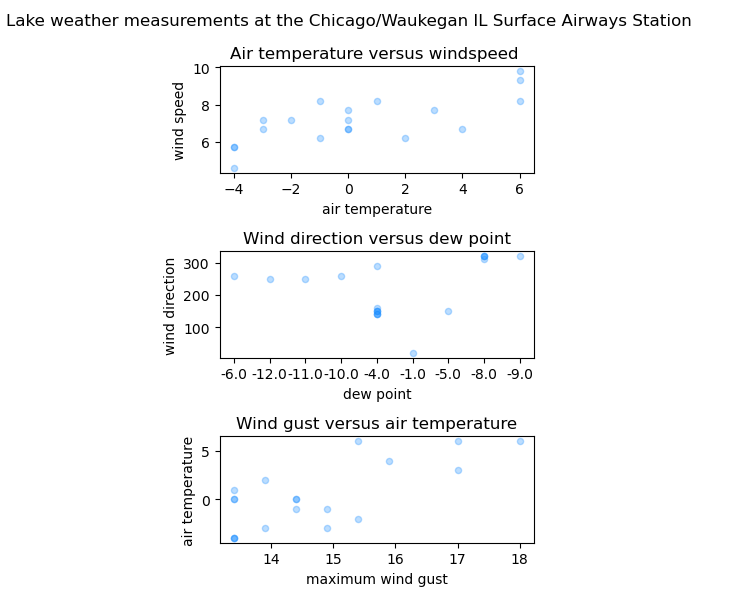

&#9989;&nbsp; **Do this (12 points):**  Use `matplotlib` to make three _scatter plots_ like the ones above. For full points, do the following:

- Create 3 subplots using `plt.subplot`. Use 3 rows and 1 column **(3 points)**.
- Use `plt.figure` and the argument `figsize` to make a plot 4 inches wide x 6 inches long **(1 point)**.
- Plot  1) `Variable 1` vs. `Variable 2`, 2) `Variable 2` vs. `Variable 3`, and 3) `Variable 1` vs. `Variable 3`. Provide a title for each subplot **(1 point)**.
- Give the overall plot an appropriate title **(1 point)**
- Provide x-axis labels **(1 point)**.
- Provide y-axis labels **(1 point)**.
- Create variables for point size, color, and alpha outside of the code for your plots. Use the variables you created to control size, color, and alpha in your subplots. Use the same parameters for all the plots. Choose appropriate point size, color, and alpha so that you can see the relationships in your data (avoid overplotting) **(3 points, one for each)**.
- Use `tight_layout` to give your plot optimal sizing **(1 points)**.

In [37]:
# Put your code here

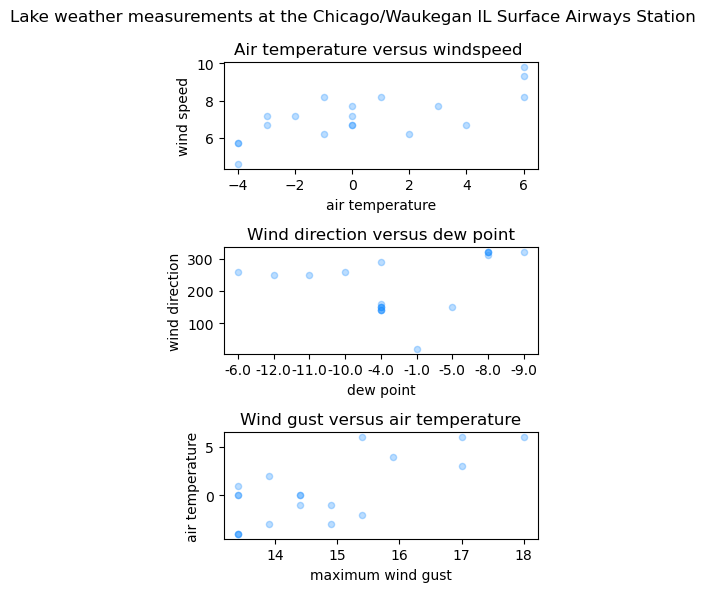

In [297]:
### ANSWER ###

size = 20
a = 0.3
col = "dodgerblue"

plt.figure(figsize=(4,6))

plt.suptitle("Lake weather measurements at the Chicago/Waukegan IL Surface Airways Station")

plt.subplot(3,1,1)
plt.scatter(data_CHI["air_temp"], data_CHI["wind_speed"], s=size, alpha=a, c=col)
plt.title("Air temperature versus windspeed ")
plt.xlabel("air temperature")
plt.ylabel("wind speed")

plt.subplot(3,1,2)
plt.scatter(data_CHI["dew_point"], data_CHI["wind_direction"], s=size, alpha=a, c=col)
plt.xlabel("dew point")
plt.ylabel("wind direction")
plt.title("Wind direction versus dew point")

plt.subplot(3,1,3)
plt.scatter(data_CHI["max_gust"], data_CHI["air_temp"], s=size, alpha=a, c=col)
plt.xlabel("maximum wind gust")
plt.ylabel("air temperature")
plt.title("Wind gust versus air temperature")

plt.tight_layout()

plt.savefig("lake_MI_plot.jpg")

In [39]:
### ANSWER ###

# -- The points are given in the text above. 
# -- Partial credit if only one of the plot has the correct characteristics.

&#9989;&nbsp; **Answer the following (3 points):** Looking at the plots, 

1. Which plots looks like it has the strongest correlation? Justify your answer (1 point).
2. Which plot looks the most linear? (1 point).
3. Which plot do you believe would be the easiest to create a model for. Justify your answer (1 point).

<font size=8 color="#009600">&#9998;</font> Put your answer here

**Part 1 (1pt):**  

**Part 2 (1pt):**  

**Part 3 (1pt):**  


In [40]:
### ANSWER ###

# --  1 point, any answer as long as justified, no partial credit
# Harvest vs anomaly looks like a strong correlation, and supported by correlation coefficients above

# --  1 point, any answer as long as justified, no partial credit
# Harvest vs anomaly looks the most linear

# --  1 point, any answer as long as justified, no partial credit
# Because it is the strongest correlation and linear, probably Harvest vs anomaly is the easiest to model

---
<a id="part_3"></a>

## Part 3: Fitting curves to data. Harvest date as a function of temperature anomaly (18 points)

[Back to Top](#toc)

Now that we have visualized our data we can formulate a question in a guided way. In this section, we will ask:

> What is the relationship between harvest date and temperature anomaly? Can we predict harvest date from temperature anomaly?

### Part 3.1: Model
In the above plots we notice that `harvest` (almost) linearly declines as `anomaly` increases in value. Specifically, 

$$ harvest  = m\times anomaly + b $$

Where $harvest$ is the harvest date represented by the variable `harvest`, $anomaly$ is the temperature anomaly in degrees Celsius represented by the variable `anomaly`, and $m$ is the slope of the line and $b$ the intercept.

&#9989;&nbsp; **Do this (4 points):** 
- Write a function called `harvest_model` that calculates harvest date based on temperature anomaly using the equation above. The equation should be constructed so that you can build a model using the `curve_fit` function in the next section.

In [41]:
# Put your code here

In [42]:
### ANSWER ###

def harvest_model(temps, m, b):
    return  temps*m +b

# 1 point for correct name
# 1 point for correct order of the inputs. No partial credit
# 1 point for correct math. No partial credit
# 1 point for return statement

### Part 3.2: Fit the model

&#9989;&nbsp; **Do this (6 points):** 

- Use a dataset without `NaN` values. To build your model, it is important that you use data without `NaN` values, otherwise you will get an error. In part 1.5, you removed `NaN` values from this dataset. If you were able to successfully remove the `NaN` values, you can use the clean dataset. Otherwise, code to read in a clean dataset by url is provided. You can uncomment out this line and use this dataset if you like. (1 point)
- Now use `curve_fit` with your `harvest_model` function to find the slope ($m$) and intercept ($b$) parameters. (4 points)
- Print out the value of the slope $m$, write "The value of the slope is..." (0.5 points)
- Print out the value of the intercept $b$, write "The value of the intercept is..." (0.5 points)

In [43]:
# Put your code here

# You can use the following url from GitHub to read in a dataset with no NaNs:
# clean_grape_df = pd.read_csv("https://raw.githubusercontent.com/DanChitwood/PlantsAndPython/master/grape_harvest.csv")


In [44]:
#### ANSWER ###

clean_grape_df = pd.read_csv("https://raw.githubusercontent.com/DanChitwood/PlantsAndPython/master/grape_harvest.csv")

popt, pcov = curve_fit(harvest_model, 
                       clean_grape_df["anomaly"], 
                       clean_grape_df["harvest"])

print("The value of the slope is", popt[0])
print("The value of the intercept is", popt[1])

# 1 point for correctly using a dataset with no NaNs
# 1 point for calling curve_fit
# 1 point for correct placement of harvest_model
# 1 point for correct placement of x values (anomaly)
# 1 point for correct placement of y values (harvest)
# 0.5 points for correctly printing out slope value
# 0.5 points for correctly printing out intercept value

The value of the slope is -5.656973497064281
The value of the intercept is 32.048523825543725


### Part 3.3 Check your model (8 points)

&#9989;&nbsp; **Do this (6 points):**  Make a plot comparing your model and the data.

- Plot the actual data (2 points)
- Plot your modeled data (2 points)
- Use x and y axis labels and title (1 point)
- Adjust the color, size, and alpha of the datapoints to avoid overplotting. Make sure the plot of your model is a different color than the datapoints so that you can see it. (1 point)

In [45]:
# Put your code here

Text(0.5, 1.0, 'Harvest date vs. temperature anomaly')

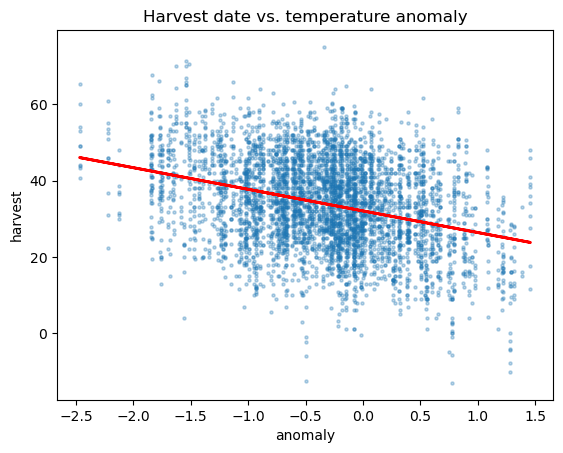

In [46]:
#### ANSWER ###

plt.scatter(clean_grape_df["anomaly"], clean_grape_df["harvest"], s=5, alpha=0.3)
plt.plot(clean_grape_df["anomaly"], harvest_model(clean_grape_df["anomaly"], popt[0], popt[1]), c="red", lw=2)
plt.xlabel("anomaly")
plt.ylabel("harvest")
plt.title("Harvest date vs. temperature anomaly")

# 2 points for plotting the data. No partial credit
# 2 points for plotting the fitted line. No partial credit
# 1 point for title and x and y axis labels. 0 points if missing even one
# 1 point for adjusting color/size/alpha of data and making sure line is different color. 0 points if no attempt

&#9989;&nbsp; **Answer the following (2 points):** 
Do you think your model is a good model? Clearly justify your answer (looking for more than a "yes" or "no" answer).

<font size=8 color="#009600">&#9998;</font> Put your answer here

In [47]:
### ANSWER ###

# 0 points if blank, 
# 0.5 points if they attempt it, but are way off or no justification 
# 1.0 point for answering but justification is confusing or contraddicting, 
# 2 points: Clearly stated answer with well-articulated justification.

# Possible answers for full credit:
# No, because even though linear, the correlation coefficient is not high
# Yes, the data follows the fitted line and the deviation is consistent across temperature values
# No, there is too much variability, there's not a lot of data at low temperature values
# Yes, because the data doesn't appear to deviate from the model, it doesn't appear non-linear

---

### Congratulations, you're done!
[Back to Top](#toc)

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" section, find the submission folder link for Homework #3, and upload it there.

&#169; 2024 Copyright the Department of Computational Mathematics, Science and Engineering.